[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module3_DeepLearning/19_DefiningNNs.ipynb#copy=true)

In [1]:
#import libraries
import torch 
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# download the MNIST data set
train = datasets.MNIST('', train=True, download=True,
                      transform=transforms.Compose(
                          [transforms.ToTensor()]))

Extracting MNIST/raw/train-images-idx3-ubyte.gz to MNIST/raw


Extracting MNIST/raw/train-labels-idx1-ubyte.gz to MNIST/raw



Extracting MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST/raw


Extracting MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST/raw
Processing...
Done!


/Users/mbanuelos/anaconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:469: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /Users/distiller/project/conda/conda-bld/pytorch_1595629449223/work/torch/csrc/utils/tensor_numpy.cpp:141.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [3]:
test = datasets.MNIST('', train=False, download=True,
                      transform=transforms.Compose(
                          [transforms.ToTensor()]))

In [4]:
# define train and test set with appropriate batch sizes
trainset = torch.utils.data.DataLoader(train, batch_size=10, 
                                       shuffle=True)
testset = torch.utils.data.DataLoader(test, batch_size=10, 
                                     shuffle=False)

* Gradient Descent - use all the data to calculate the gradient
* Stochastic Gradient Descent (SGD) - use a random sample in the data to calculate the gradient
* Mini-Batch Descent - partition the data and then calculate the gradient w.r.t the data in the partition
  * Once you have done this for all partitions, this is known as an epoch

In [24]:
class Net(nn.Module):
    def __init__(self):
        # inherit the class attributes of nn.module
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 10)
        
    # define forward method where x is the data
    def forward(self, x):
        # output of layer 1
        x = F.relu(self.fc1(x))
        # output of layer 2
        x = F.relu(self.fc2(x))
        # output of layer 3
        x = F.relu(self.fc3(x))
        # output of layer 4
        x = self.fc4(x)
        return F.log_softmax(x, dim=1)

In [25]:
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [26]:
model.parameters()

<generator object Module.parameters at 0x7fab712785f0>

In [27]:
# next, we need a loss function and an optimizer

import torch.optim as optim

loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
# let's run it -- let's train the model

for epoch in range(3):
    for batch in trainset:
        X, y = batch # X is the features, y is the labels
        # zero gradients
        model.zero_grad()
        # input the data
        out = model(X.view(-1,784))
        # calculate the loss
        loss = loss_fun(out, y)
        # calculate gradients
        loss.backward()
        # update parameters
        optimizer.step()
    print(loss)

tensor(0.0035, grad_fn=<NllLossBackward>)
tensor(0.0692, grad_fn=<NllLossBackward>)
tensor(0.0004, grad_fn=<NllLossBackward>)


In [38]:
# let's check out the test accuracy

correct = 0
total = 0

# do not update the gradients anymore
with torch.no_grad():
    for batch in testset:
        X, y = batch
        out = model(X.view(-1, 784))
        for idx, i in enumerate(out):
            #print(idx)
            #print(i)
            #print(y[idx])
            #print(torch.argmax(i))
            if torch.argmax(i) == y[idx]:
                # add one to the number correct
                correct += 1
            # update your total
            total += 1

print('Accuracy: ', correct/total)

Accuracy:  0.9683


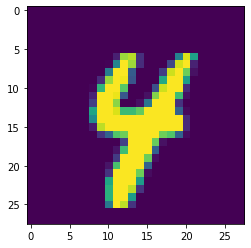

In [33]:
import matplotlib.pyplot as plt

plt.imshow(X[7].view(28,28))
plt.show()

In [34]:
# what does the model predict?
pred1 = model(X[7].view(-1,784))[0]
prediction = torch.argmax(pred1)
print(prediction)

tensor(4)
